<a href="https://colab.research.google.com/github/rafael-sfernandes/customer-clustering/blob/main/notebooks/customer_clustering_RFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Context
A UK e-commerce company needs to cluster its customers based on RFM metrics (discussed below) in order to define loyalty strategies.

RFM:

- R (Recency): Time since the customer's last purchase (in days)
- F (Frequency): Number of purchases made by the customer
- M (Monetary): Average order value spent by the customer

The provided dataset contains transactions that occurred between December 2010 and December 2011.

Your goal is to cluster customers based on their RFM metrics.

Dataset Source (Original Data Source - Kaggle) [This link](https://www.kaggle.com/datasets/carrie1/ecommerce-data).

#0. Setup

In [254]:
%%capture
%pip install sidetable

In [255]:
#Math
import numpy as np

#Data
import pandas as pd
import sidetable

#Graphics
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

#ML
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN, MeanShift, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, scale

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from yellowbrick.cluster import kelbow_visualizer

#Scripts
import scripts as scr

In [256]:
# Graphics custom

# https://matplotlib.org/stable/tutorials/introductory/customizing.html

sns.set_theme(
    context='talk',
    style='ticks',
    font_scale=.8,
    palette='tab10',
    rc={
        'figure.figsize': (12,8),
        'axes.grid': True,
        'grid.alpha': .2,
        'axes.titlesize': 'x-large',
        'axes.titleweight': 'bold',
        'axes.titlepad': 20,
    }
)

#1. Data Loading

In [257]:
# Loading
df = pd.read_csv("https://raw.githubusercontent.com/rafael-sfernandes/customer-clustering/refs/heads/main/data/e-commerce.csv", encoding='latin1')

#2. Data Understanding

## 2.1. Variables Description

In [258]:
# Data visualization
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


###**`InvoiceNo`**:
It's the purchase ID. Should't have null values, as we are taking only purchases data. The same ID could repeat when there are more than one item bought by the customer on the purchase. For example: rows 0 and 1 shows the same `InvoiceNo` 536365, but each line register a different stock code (distinct products). It's one purchase with many items. Check below, we have 7 distinct item bought in the `InvoiceNo` 536365.

In [259]:
# Checking 'InvoiceNo'
df[df['InvoiceNo'] == '536365'].shape[0]

7

###**`StockCode`**:
It's the item code tha was bought on the purchase. Over 4k distinct products in stock. Shoudn't have null values and there may be repetitions.

In [260]:
# Checking 'StockCode'
df['StockCode'].nunique()

4070

###**`Description`**:
The name of the item and some properties. There may be null values and duplicates.

###**`Quantity`**:
The quantity of this item that was bought in the purchase. For example: There are 6 units of the item 85123A in the purchase 536365. Check below. Would be strange have null values. There are only integer numbers.

Numeric column.

In [261]:
# Checking the first row
df.iloc[0,:]

,0
InvoiceNo,536365
StockCode,85123A
Description,WHITE HANGING HEART T-LIGHT HOLDER
Quantity,6
InvoiceDate,12/1/2010 8:26
UnitPrice,2.55
CustomerID,17850.0
Country,United Kingdom


In [262]:
# Checking integer values
(df['Quantity'] - df['Quantity'].astype(int)).value_counts()

,count
Quantity,
0,541909


###**`InvoiceDate`**:
It's the date and time stamp of the purchase. Must be treated as datetime type.

###**`UnitPrice`**:
It's the value of the product. Must be an float number. There may be null values and duplicates. With this in hands we can get the total of the item in each purchase, as we can get the purchase total.

Numeric column.

###**`CustomerID`**:
It's the ID of who done the purchase. There may be null values to check and duplicates, because the same customer can purchase mora than one time. Must be treated as an object type. There are over 4k distinct customers.

In [263]:
# Checking distinct customers
df['CustomerID'].nunique()

4372

###**`Country`**:
It's the country from where the purchase was made or the customer's country. Must be an object and there may be duplicates. We can check below that there are some customers with more than one country purchase. This bring us a little doubt: the country it's the country purchase or maybe the customer has changed his address?

In [264]:
# Checking existence of customers with more than 1 country purchase
df.groupby('CustomerID')['Country'].nunique().value_counts()

,count
Country,
1,4364
2,8


In [265]:
# Filtering customers ID with 2 distinct countries purchases
df.groupby('CustomerID')['Country'].nunique()[df.groupby('CustomerID')['Country'].nunique() == 2]

,Country
CustomerID,
12370.0,2
12394.0,2
12417.0,2
12422.0,2
12429.0,2
12431.0,2
12455.0,2
12457.0,2


In [266]:
# Getting previous customer's ID
indexes = df.groupby('CustomerID')['Country'].nunique()[df.groupby('CustomerID')['Country'].nunique() == 2].index

In [267]:
# Counting purchases from each country for each customer.
(
    df[df['CustomerID'].isin(indexes)]        # Customer filter with multiple distinct countries
    .value_counts(['CustomerID', 'Country'])  # Counting CustomerID purchases for each Country
    .sort_index()                             # Sort by MultiIndex
    .reset_index(name='Quantity')             # Index adjust from MultiIndex to RangeIndex
)

,CustomerID,Country,Quantity
0,12370.0,Austria,8
1,12370.0,Cyprus,159
2,12394.0,Belgium,21
3,12394.0,Denmark,6
4,12417.0,Belgium,175
5,12417.0,Spain,23
6,12422.0,Australia,21
7,12422.0,Switzerland,18
8,12429.0,Austria,21
9,12429.0,Denmark,76


##2.2. Exploration

###Report

**Work to do**

*   Snake case columns names
*   `StockCode` can be droped
*   `Description` have null values and it's a categoric column.
*   `Quantity` have negative values.
*   `InvoiceDate` must be Datetime.
*   `UnitPrice` have negative values.
*   `CustomerID` could be integer and have negative numbers. All customers Id's endswith '.0' and remaining are null values. This allows us to work with integers.
*   `Country`it's a categoric column.
*   Check Outliers.

###

In [268]:
# Checking first rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [269]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [270]:
# Unique values number by column
df.nunique()

,0
InvoiceNo,25900
StockCode,4070
Description,4223
Quantity,722
InvoiceDate,23260
UnitPrice,1630
CustomerID,4372
Country,38


In [271]:
# Checking 'InvoiceNo' values (there are letters)
df['InvoiceNo'].value_counts()

,count
InvoiceNo,
573585,1114
581219,749
581492,731
580729,721
558475,705
...,...
581483,1
581566,1
C581499,1


In [272]:
# Checking unique values in category columns
df[['Description', 'Country']].nunique()

,0
Description,4223
Country,38


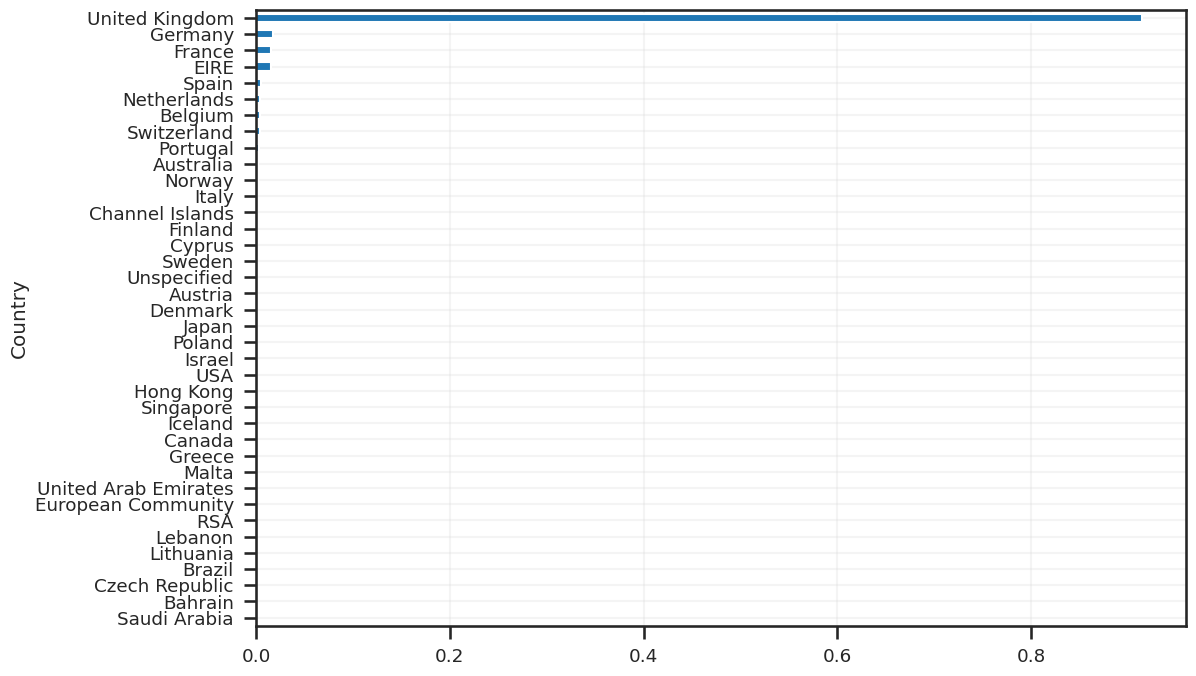

In [273]:
# Countries frequency plot
df['Country'].value_counts(normalize=True, ascending=True).plot.barh(figsize=(12,8));

In [274]:
# Countries cumulative table
df.stb.freq(['Country'])

,Country,count,percent,cumulative_count,cumulative_percent
0,United Kingdom,495478,91.431956,495478,91.431956
1,Germany,9495,1.752139,504973,93.184095
2,France,8557,1.579047,513530,94.763143
3,EIRE,8196,1.512431,521726,96.275574
4,Spain,2533,0.467422,524259,96.742996
5,Netherlands,2371,0.437527,526630,97.180523
6,Belgium,2069,0.381798,528699,97.562321
7,Switzerland,2002,0.369435,530701,97.931756
8,Portugal,1519,0.280305,532220,98.212061
9,Australia,1259,0.232327,533479,98.444388


In [275]:
# Null values number by column
df.isna().sum().sort_values(ascending=False)

,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [276]:
# Duplicated rows
df.duplicated().sum()

np.int64(5268)

In [277]:
# Checking negative values
df['UnitPrice'].value_counts().sort_index()

,count
UnitPrice,
-11062.060,2
0.000,2515
0.001,4
0.010,1
0.030,3
...,...
13541.330,3
16453.710,1
16888.020,1


In [278]:
# Checking negative values
df['Quantity'].value_counts().sort_index()

,count
Quantity,
-80995,1
-74215,1
-9600,2
-9360,1
-9058,1
...,...
4800,1
5568,1
12540,1


In [279]:
# Filtering every float ending with '.0'
filter = df['CustomerID'].astype(str).str.endswith('.0')

In [280]:
# Checking the number os customers with this '.0' pattern
n1 = df[filter].shape[0]

In [281]:
# Checking null values in the column 'CustomerID'
n2 = df['CustomerID'].isna().sum()

In [282]:
# Both merges in the full column, this means that all customers with ID ends with '.0' pattern
n1+n2

np.int64(541909)

#3. Data Preparation

##3.1. Data Cleaning

In [283]:
# Snake Case column names
df.columns = [snake_case(col) for col in df.columns]

We can check for about 25% missing values of customers. As we need to clusterize taking the RFM, we can't calculate the Monetary per customer if we don't know who is him. We need this information. So we have some options:


1.   Ask the company for the customers data.
2.   Drop all missing if we don't have this information.



In [284]:
# Checking missing values with sidetable
df.stb.missing()

,missing,total,percent
customer_id,135080,541909,24.926694
description,1454,541909,0.268311
stock_code,0,541909,0.000000
invoice_no,0,541909,0.000000
quantity,0,541909,0.000000
invoice_date,0,541909,0.000000
unit_price,0,541909,0.000000
country,0,541909,0.000000


In [285]:
# Drop null values
df = df.dropna(subset=['customer_id'])

In [287]:
# Type datetime
%%timeit
pd.to_datetime(df['invoice_date'])

The slowest run took 6.19 times longer than the fastest. This could mean that an intermediate result is being cached.
317 ms ± 202 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [293]:
# Type datetime with format parameter (better processing)
%%timeit
pd.to_datetime(df['invoice_date'], format='%m/%d/%Y %H:%M')

19.8 ms ± 4.54 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [292]:
# Setting type
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%m/%d/%Y %H:%M')

/tmp/ipykernel_5088/2618880244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%m/%d/%Y %H:%M')


In [298]:
# Setting other types
df['customer_id'] = df['customer_id'].astype(int)
df['country'] = df['country'].astype('category')

In [300]:
# Updating DataFrame
df = df.copy()

In [301]:
# Checking informations (Dtypes)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    406829 non-null  object        
 1   stock_code    406829 non-null  object        
 2   description   406829 non-null  object        
 3   quantity      406829 non-null  int64         
 4   invoice_date  406829 non-null  datetime64[ns]
 5   unit_price    406829 non-null  float64       
 6   customer_id   406829 non-null  int64         
 7   country       406829 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 25.2+ MB


In [325]:
# Checking dataframe period
df.invoice_date.agg(['min', 'max'])

,invoice_date
min,2010-12-01 08:26:00
max,2011-12-09 12:50:00


##3.2. Data Wrangling

In [338]:
# Filtering negative values
negative_values = df[['quantity', 'unit_price']].le(0).any(axis=1)

Negative values doesn't matter. We can think as a discount value, but this don't help us with the RFM metrics. It could be an error. Anyway, we don't need to use these kind of values. So we can forget them and stay only with positive values.

In [343]:
# Checking negative quantity or unit_price rows
df[negative_values]

/tmp/ipykernel_5088/1408619014.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[negative_values]


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country


In [342]:
# Updating the DataFrame
df = df[~negative_values].copy()

/tmp/ipykernel_5088/426993492.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[~negative_values].copy()


<Axes: >

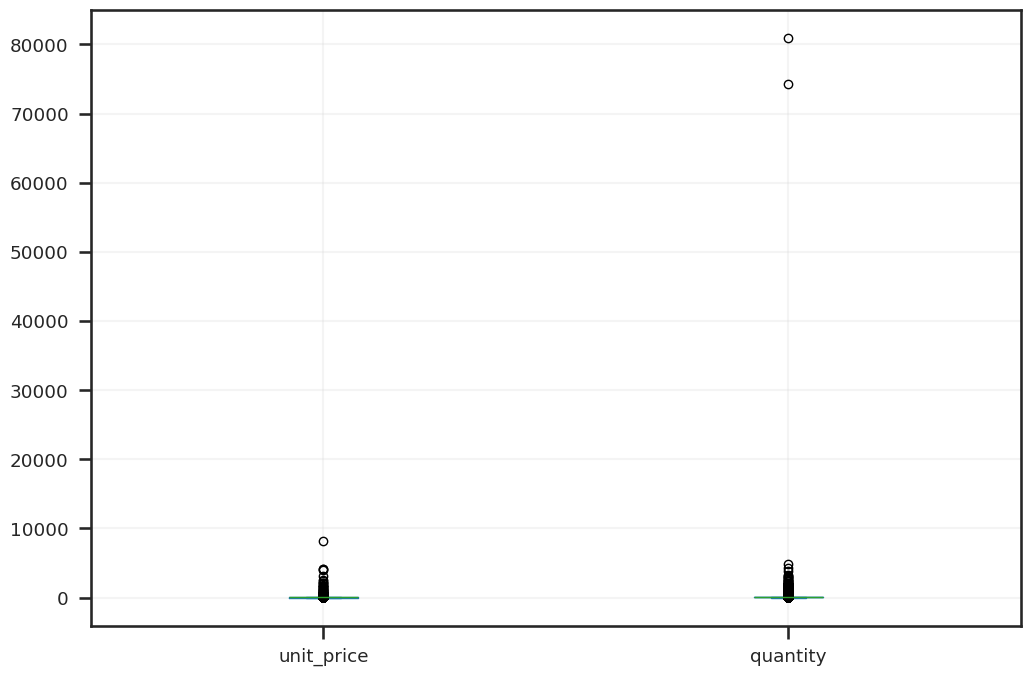

In [351]:
# Checking outliers in boxplots
df[['unit_price', 'quantity']].plot.box()